# Cross-Sport Player Similarity (NBA ↔ Premier League)

This notebook maps NBA basketball players and English Premier League soccer players into a shared **7-dimensional "universal attribute" space** (scoring, playmaking, defensive impact, efficiency, versatility, physical dominance, durability) and computes cosine similarity between every player pair. The result lets you find a player's closest analogue in the *other* sport, visualize the combined pool with 3D UMAP, and auto-generate natural-language comparison write-ups.

## Table of Contents
1. **Universal attribute definitions** — the 7 shared traits and the per-sport stat mappings
2. **Data loading & cleaning** — NBA per-minute + advanced stats, Premier League per-90 stats
3. **Percentile scoring** — rank every mapped stat within each sport's pool
4. **Attribute vectors** — weighted schema → 7-dim vector per player, min-max rescaled & z-scored
5. **Cosine similarity matrix** — pairwise similarity across the combined pool
6. **Query & inspection helpers** — `most_similar`, `explain`, and sanity checks (Jokić, Haaland)
7. **Comparison data + LLM explanation** — structured payload and Gemini write-up
8. **Visualizations** — radar charts and an interactive 3D UMAP embedding
9. **Exports** — player index, UMAP coords, similarity matrix, DNA labels, quality scores

## Data Sources
- **Basketball:** Basketball-Reference NBA 2025–26 per-minute stats — https://www.basketball-reference.com/leagues/NBA_2026_per_minute.html (plus advanced stats from the same site)
- **Soccer:** "Football Players Stats 2024-2025" (Kaggle, Hubert Sidorowicz) — https://www.kaggle.com/datasets/hubertsidorowicz/football-players-stats-2024-2025?resource=download&select=players_data-2024_2025.csv

## Key Dependencies
`pandas`, `numpy`, `scikit-learn` (`MinMaxScaler`, `cosine_similarity`), `matplotlib`, `umap-learn`, `plotly`, and `google-generativeai` + `python-dotenv` (set `GEMINI_API_KEY` in a `.env` file for the LLM explanation cell).

In [1]:
# All shared imports for the notebook. `import umap` stays in the UMAP cell below
# because it must run *after* the `!pip install umap-learn` cell.
import os

import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from dotenv import load_dotenv
import google.generativeai as genai

/Users/bryan.shao/Library/Python/3.9/lib/python/site-packages/google/api_core/_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/bryan.shao/Library/Python/3.9/lib/python/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/bryan.shao/Library/Python/3.9/lib/python/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will upda

In [2]:
# The 7 universal attributes every player is scored on (shared across both sports).
UNIVERSAL_ATTRIBUTES = [
    "scoring",
    "playmaking",
    "defensive_impact",
    "efficiency",
    "versatility",
    "physical_dominance",
    "durability"
]

In [3]:
# Maps each universal attribute to the raw stat columns that feed it, per sport.
basketball_mapping = {
    "scoring": ["PTS", "TS%", "USG%"],
    "playmaking": ["AST", "TOV", "TOV%"],
    "defensive_impact": ["STL", "BLK", "DRB", "DWS"],
    "efficiency": ["TS%", "eFG%", "FG%", "FT%", "PER"],
    "versatility": ["PTS", "AST", "TRB", "STL", "BLK"],
    "physical_dominance": ["TRB", "BLK", "FTA"],
    "durability": ["MP", "G"]
}

soccer_mapping = {
    "scoring":           ["Gls", "npxG", "G/Sh", "G/SoT", "SoT/90"],
    "playmaking":        ["Ast", "xAG", "PrgP", "PrgC", "SCA90"],
    "defensive_impact":  ["TklW", "Int", "Blocks_stats_defense", "Clr", "Recov", "Tkl%"],
    "efficiency":        ["G/SoT", "Cmp%", "npxG", "xAG"],
    "versatility":       ["Gls", "Ast", "TklW", "PrgP", "SCA90"],
    "physical_dominance":["Won%", "Clr", "Blocks_stats_defense", "Fld_stats_misc"],
    "durability":        ["Min", "Starts"],
}

In [4]:
# Load both CSVs
df = pd.read_csv('data/nba-stats.csv')
df_advanced = pd.read_csv('data/nba-advanced-stats.csv')

# Clean both the same way
df = df[df['Player'] != 'Player']
df = df.drop_duplicates(subset='Player', keep='first')

df_advanced = df_advanced[df_advanced['Player'] != 'Player']
df_advanced = df_advanced.drop_duplicates(subset='Player', keep='first')

# Merge on Player
df = df.merge(df_advanced, on='Player', suffixes=('', '_adv'))

# Filter to meaningful playing time
df['MP'] = df['MP'].astype(float)
df['G'] = df['G'].astype(float)
df = df[(df['MP'] / df['G']) > 20].copy()
df = df.reset_index(drop=True)

print(df.shape)
print(df.columns.tolist())  # see all available columns

(290, 61)
['Rk', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Awards', 'Player-additional', 'Rk_adv', 'Age_adv', 'Team_adv', 'Pos_adv', 'G_adv', 'GS_adv', 'MP_adv', 'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'Awards_adv', 'Player-additional_adv']


In [5]:
# Sanity check: the five highest-scoring players in the cleaned NBA pool.
if 'PTS' in df.columns:
    top5_pts = df.nlargest(5, 'PTS')
elif 'PTS' in df_advanced.columns:
    top5_pts = df_advanced.nlargest(5, 'PTS')
else:
    raise KeyError("No PTS column found in df or df_advanced")

display(top5_pts)

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,Awards_adv,Player-additional_adv
228,270.0,Giannis Antetokounmpo,31.0,MIL,PF,36.0,36.0,1039.0,12.9,20.7,...,3.9,1.1,5.0,0.231,7.7,1.8,9.5,3.0,AS,antetgi01
36,37.0,Luka Dončić,26.0,LAL,PG,64.0,64.0,2289.0,10.9,22.9,...,6.6,2.9,9.5,0.199,8.0,1.3,9.3,6.6,MVP-4CPOY-8ASNBA1,doncilu01
44,45.0,Shai Gilgeous-Alexander,27.0,OKC,PG,68.0,68.0,2259.0,11.6,21.1,...,11.1,4.1,15.2,0.323,8.7,3.0,11.7,7.8,MVP-1CPOY-1ASNBA1,gilgesh01
65,66.0,Kawhi Leonard,34.0,LAC,SF,65.0,65.0,2085.0,11.0,21.7,...,6.5,2.7,9.2,0.212,7.4,0.6,8.0,5.3,MVP-7CPOY-10ASNBA2,leonaka01
267,429.0,Ty Jerome,28.0,MEM,SG,15.0,15.0,339.0,10.8,22.8,...,1.1,0.2,1.3,0.191,8.2,-0.6,7.7,0.8,NaN,jeromty01


In [6]:
# Load Premier League stats, dedupe transfers, convert counting stats to per-90, drop GKs.
soccer_df = pd.read_csv('data/soccer-stats.csv')

# Filter to Premier League only
soccer_df = soccer_df[soccer_df['Comp'] == 'eng Premier League']

# Keep row with most minutes for players who transferred
soccer_df = soccer_df.sort_values('Min', ascending=False)
soccer_df = soccer_df.drop_duplicates(subset='Player', keep='first')

# Filter to meaningful playing time
soccer_df = soccer_df[soccer_df['Min'].astype(float) > 900].copy()
rate_cols = ['Gls', 'Ast', 'xG', 'npxG', 'xAG', 'KP', 'PrgP', 'PrgC',
             'Tkl', 'TklW', 'Int', 'Clr', 'Blocks_stats_defense', 'Recov']
for col in rate_cols:
    if col in soccer_df.columns:
        soccer_df[col] = soccer_df[col].astype(float) / soccer_df['90s'].astype(float)

# Filter out goalkeepers
soccer_df = soccer_df[soccer_df['Pos'].str.split(',').str[0] != 'GK'].copy()

# Reset index
soccer_df = soccer_df.reset_index(drop=True)

soccer_df[soccer_df['Player'].str.contains('Haaland')][['Player', 'Gls', 'Ast']]

,Player,Gls,Ast
64,Erling Haaland,0.723684,0.098684


In [7]:
# ---- Convert stats to percentile scores across the full pool (no position grouping) ----
# Each player is ranked against all players in their sport regardless of position.
# Percentile = ascending rank in [0, 1] (1.0 = best in pool for that stat).
# Note: lower-is-better stats (e.g. TOV%) are NOT inverted here.

def position_percentiles(data, pos, mapping):
    """Percentile-rank each mapped stat within position groups.

    data    : source DataFrame
    pos     : Series of position-group labels aligned to data.index
    mapping : dict attribute -> list of stat columns
    Returns a DataFrame with one <stat>_pct column per available mapped stat.
    """
    stat_cols = list(dict.fromkeys(c for cols in mapping.values() for c in cols))

    available = [c for c in stat_cols if c in data.columns]
    missing = [c for c in stat_cols if c not in data.columns]
    if missing:
        print(f"  skipping {len(missing)} derived/unmapped columns: {missing}")

    out = pd.DataFrame(index=data.index)
    for col in available:
        vals = pd.to_numeric(data[col], errors='coerce')
        out[f"{col}_pct"] = vals.groupby(pos).rank(pct=True)
    return out


# NBA: rank all players together regardless of position
nba_pos = pd.Series('all', index=df.index)
nba_pct = position_percentiles(df, nba_pos, basketball_mapping)
nba_pct.insert(0, 'Pos', df['Pos'].values)
nba_pct.insert(0, 'Player', df['Player'].values)

# Soccer: rank all outfield players together regardless of position
soccer_pos = pd.Series('all', index=soccer_df.index)
soccer_pct = position_percentiles(soccer_df, soccer_pos, soccer_mapping)
soccer_pct.insert(0, 'Pos', soccer_df['Pos'].str.split(',').str[0].values)
soccer_pct.insert(0, 'Player', soccer_df['Player'].values)

print("NBA percentiles:", nba_pct.shape, "| Soccer percentiles:", soccer_pct.shape)

# sanity check: Jokić and Haaland
display(nba_pct[nba_pct['Player'].str.contains('Joki', na=False)])
display(soccer_pct[soccer_pct['Player'].str.contains('Haaland', na=False)])

NBA percentiles: (290, 20) | Soccer percentiles: (295, 23)


,Player,Pos,PTS_pct,TS%_pct,USG%_pct,AST_pct,TOV_pct,TOV%_pct,STL_pct,BLK_pct,DRB_pct,DWS_pct,eFG%_pct,FG%_pct,FT%_pct,PER_pct,TRB_pct,FTA_pct,MP_pct,G_pct
42,Nikola Jokić,C,0.962069,0.948276,0.936207,0.996552,0.965517,0.836207,0.753448,0.701724,0.987931,0.934483,0.906897,0.903448,0.698276,0.996552,0.965517,0.948276,0.855172,0.534483


,Player,Pos,Gls_pct,npxG_pct,G/Sh_pct,G/SoT_pct,SoT/90_pct,Ast_pct,xAG_pct,PrgP_pct,...,Int_pct,Blocks_stats_defense_pct,Clr_pct,Recov_pct,Tkl%_pct,Cmp%_pct,Won%_pct,Fld_stats_misc_pct,Min_pct,Starts_pct
64,Erling Haaland,FW,0.989831,1.0,0.883051,0.689046,1.0,0.583051,0.576271,0.00339,...,0.054237,0.047458,0.189831,0.00339,0.186441,0.064407,0.632203,0.301695,0.783051,0.767797


In [8]:
# Per-sport weighting: how strongly each stat contributes to each universal attribute.
universal_schema = {
    "basketball": {
        "scoring": {
            "PTS": 0.60,
            "TS%": 0.20,
            "USG%": 0.20,
        },
        "playmaking": {
            "AST": 1.1,
            "TOV%": -0.1,
        },
        "defensive_impact": {
            "DWS": 0.50,
            "STL": 0.10,
            "BLK": 0.10,
            "DRB": 0.30,
        },
        "efficiency": {
            "TS%": 0.35,
            "eFG%": 0.25,
            "PER": 0.20,
            "FG%": 0.10,
            "FT%": 0.10,
        },
        "versatility": {
            "PTS": 0.30,
            "AST": 0.25,
            "TRB": 0.20,
            "STL": 0.15,
            "BLK": 0.10,
        },
        "physical_dominance": {
            "TRB": 0.45,
            "FTA": 0.35,
            "BLK": 0.20,
        },
        "durability": {
            "MP": 0.60,
            "G": 0.40,
        },
    },

    "soccer": {
        "scoring": {
            "Gls":     0.35,
            "npxG":    0.30,
            "G/SoT":   0.20,
            "SoT/90":  0.10,
            "G/Sh":    0.05,
        },
        "playmaking": {
            "xAG":    0.35,
            "Ast":    0.25,
            "PrgP":   0.20,
            "SCA90":  0.10,
            "PrgC":   0.10,
        },
        "defensive_impact": {
            "Int":                  0.25,
            "TklW":                 0.25,
            "Recov":                0.20,
            "Blocks_stats_defense": 0.15,
            "Clr":                  0.10,
            "Tkl%":                 0.05,
        },
        "efficiency": {
            "G/SoT":  0.35,
            "Cmp%":   0.30,
            "npxG":   0.20,
            "xAG":    0.15,
        },
        "versatility": {
            "Gls":    0.25,
            "Ast":    0.25,
            "TklW":   0.20,
            "PrgP":   0.15,
            "SCA90":  0.15,
        },
        "physical_dominance": {
            "Won%":                 0.45,
            "Clr":                  0.30,
            "Blocks_stats_defense": 0.15,
            "Fld_stats_misc":       0.10,
        },
        "durability": {
            "Min":    0.60,
            "Starts": 0.40,
        },
    },
}


In [9]:
# ---- Vectorize each player into the 7 universal-attribute scores ----
# attribute_score = sum(weight * position-relative percentile) over the
# stats mapped to that attribute. Negative weights penalize bad stats.

def build_attribute_vectors(pct_df, sport_schema):
    vectors = pd.DataFrame(index=pct_df['Player'].values)
    for attribute, weights in sport_schema.items():
        score = np.zeros(len(pct_df))
        for stat, w in weights.items():
            col = f"{stat}_pct"
            if col not in pct_df.columns:
                print(f"  note: {col} missing from percentile table; neutral-filling 0.5")
                pct = pd.Series(0.5, index=pct_df.index)
            else:
                pct = pd.to_numeric(pct_df[col], errors='coerce').fillna(0.5)
            score = score + w * pct.values
        vectors[attribute] = score
    vectors.index.name = 'Player'
    return vectors


ATTRS = list(universal_schema['basketball'].keys())

nba_vectors = build_attribute_vectors(nba_pct, universal_schema['basketball'])
soccer_vectors = build_attribute_vectors(soccer_pct, universal_schema['soccer'])


# ---- Min-max rescale each sport independently ----

def rescale_vectors(vec_df):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(vec_df)
    return pd.DataFrame(scaled, index=vec_df.index, columns=vec_df.columns)

nba_vectors = rescale_vectors(nba_vectors)
soccer_vectors = rescale_vectors(soccer_vectors)

print("nba_vectors", nba_vectors.shape, "| soccer_vectors", soccer_vectors.shape)
nba_vectors.head()

nba_vectors (290, 7) | soccer_vectors (295, 7)


,scoring,playmaking,defensive_impact,efficiency,versatility,physical_dominance,durability
Player,,,,,,,
Amen Thompson,0.544144,0.736785,0.801347,0.661545,0.692885,0.713211,0.981729
Kevin Durant,0.919100,0.680515,0.746165,0.903182,0.659295,0.646697,0.972593
Desmond Bane,0.752023,0.664393,0.556678,0.710364,0.560505,0.453394,1.000000
Toumani Camara,0.319733,0.286312,0.637486,0.428727,0.343105,0.337156,0.997892
Jabari Smith Jr.,0.402392,0.140133,0.777778,0.421182,0.337263,0.576055,0.950808


In [10]:
# ---- Combine both sports and z-score each attribute across the pool ----
# Shared mean/std so each trait is centered and contributes comparably to cosine.

combined = pd.concat([
    nba_vectors.assign(sport='basketball'),
    soccer_vectors.assign(sport='soccer'),
])
assert combined.index.is_unique, "player name collision across sports"

mu = combined[ATTRS].mean()
sigma = combined[ATTRS].std(ddof=0)

vectors_z = combined.copy()
vectors_z[ATTRS] = (combined[ATTRS] - mu) / sigma
sport_of = vectors_z['sport']  # Series: Player -> 'basketball' | 'soccer'


In [11]:
# ---- Cosine similarity over the standardized pool (597 x 597) ----

_sim = cosine_similarity(vectors_z[ATTRS].values)
sim_matrix = pd.DataFrame(_sim, index=vectors_z.index, columns=vectors_z.index)


/Users/bryan.shao/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bryan.shao/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bryan.shao/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [12]:
# ---- Query & inspection helpers ----

def most_similar(player, n=10, scope='opposite'):
    """Top-N most similar players to `player`.

    scope: 'opposite' (other sport, default) | 'same' (same sport) | 'all'.
    Returns a DataFrame of player, sport, similarity (descending).
    """
    if player not in sim_matrix.index:
        raise KeyError(f"{player!r} not found")
    target_sport = sport_of[player]
    scores = sim_matrix[player].drop(player)         # exclude self
    others = sport_of.drop(player)
    if scope == 'opposite':
        scores = scores[others != target_sport]
    elif scope == 'same':
        scores = scores[others == target_sport]
    elif scope != 'all':
        raise ValueError("scope must be 'opposite', 'same', or 'all'")
    scores = scores.sort_values(ascending=False).head(n)
    return pd.DataFrame({
        'player': scores.index,
        'sport': sport_of[scores.index].values,
        'similarity': scores.values,
    }).reset_index(drop=True)


def explain(player_a, player_b):
    """Side-by-side 7-attribute profiles (raw and standardized) for two players."""
    print(f"cosine similarity: {sim_matrix.loc[player_a, player_b]:.3f}")
    return pd.DataFrame({
        f'{player_a} (raw)': combined.loc[player_a, ATTRS],
        f'{player_b} (raw)': combined.loc[player_b, ATTRS],
        f'{player_a} (z)':   vectors_z.loc[player_a, ATTRS],
        f'{player_b} (z)':   vectors_z.loc[player_b, ATTRS],
    })


# sanity checks
_jokic = most_similar("Nikola Jokić")
assert (_jokic['sport'] == 'soccer').all()            # opposite-sport only
assert _jokic['similarity'].is_monotonic_decreasing   # ranked
assert len(_jokic) == 10
assert (most_similar("Erling Haaland")['sport'] == 'basketball').all()
assert (most_similar("Nikola Jokić", scope='same')['sport'] == 'basketball').all()

# demo
print("Most like Nikola Jokić (soccer):")
display(_jokic)
print("Most like Erling Haaland (NBA):")
display(most_similar("Erling Haaland"))
display(explain("Nikola Jokić", _jokic.iloc[0]['player']))

Most like Nikola Jokić (soccer):


,player,sport,similarity
0,Joelinton,soccer,0.955861
1,Lucas Paquetá,soccer,0.853878
2,Alexis Mac Allister,soccer,0.850029
3,Sandro Tonali,soccer,0.849352
4,Dango Ouattara,soccer,0.834133
5,Rayan Aït-Nouri,soccer,0.826980
6,Thomas Partey,soccer,0.822045
7,Declan Rice,soccer,0.822031
8,Mateo Kovačić,soccer,0.821611
9,Bruno Guimarães,soccer,0.818452


Most like Erling Haaland (NBA):


,player,sport,similarity
0,Brice Sensabaugh,basketball,0.981957
1,DeMar DeRozan,basketball,0.819520
2,Saddiq Bey,basketball,0.816178
3,CJ McCollum,basketball,0.743550
4,Jerami Grant,basketball,0.727071
5,Zach LaVine,basketball,0.718230
6,Keyonte George,basketball,0.696039
7,Kyle Kuzma,basketball,0.667469
8,Collin Sexton,basketball,0.657715
9,Norman Powell,basketball,0.649442


cosine similarity: 0.956


,Nikola Jokić (raw),Joelinton (raw),Nikola Jokić (z),Joelinton (z)
scoring,0.968695,0.643436,1.76842,0.569465
playmaking,0.969772,0.598511,1.785754,0.379106
defensive_impact,0.944257,0.779884,1.79678,1.094656
efficiency,0.958727,0.670912,1.934249,0.663913
versatility,1.0,0.70974,2.456988,1.018092
physical_dominance,0.915963,0.688026,1.849277,0.858061
durability,0.737175,0.670765,0.807851,0.576912


In [13]:
# Demo: nearest cross-sport and same-sport matches for a chosen test player.
test_players = [
    "Virgil van Dijk",
]

for player in test_players:
    if player not in sim_matrix.index:
        print(f"\n{player} — NOT FOUND in dataset")
        continue
    
    sport = sport_of[player]
    print(f"\n{'='*50}")
    print(f"Most like {player} ({sport}) — cross-sport:")
    display(most_similar(player, n=5, scope='opposite'))
    print(f"Most like {player} ({sport}) — same-sport:")
    display(most_similar(player, n=5, scope='same'))


Most like Virgil van Dijk (soccer) — cross-sport:


,player,sport,similarity
0,Maxime Raynaud,basketball,0.859984
1,Wendell Carter Jr.,basketball,0.859182
2,Jay Huff,basketball,0.821141
3,Rudy Gobert,basketball,0.818962
4,Deandre Ayton,basketball,0.769546


Most like Virgil van Dijk (soccer) — same-sport:


,player,sport,similarity
0,Levi Colwill,soccer,0.973570
1,Nikola Milenković,soccer,0.950928
2,Nathan Collins,soccer,0.937301
3,William Saliba,soccer,0.927368
4,Ibrahima Konaté,soccer,0.907748


In [14]:
# Inspect specific cross-sport pairs side by side with explain().
pairs = [
    ("Rudy Gobert", "Trae Young"),
    ("Jrue Holiday", "Bruno Fernandes"),
    ("Erling Haaland", "Declan Rice"),
]

for a, b in pairs:
    if a not in sim_matrix.index:
        print(f"{a} NOT FOUND"); continue
    if b not in sim_matrix.index:
        print(f"{b} NOT FOUND"); continue
    print(f"\n{a} vs {b}: {sim_matrix.loc[a, b]:.4f}")
    display(explain(a, b))


Rudy Gobert vs Trae Young: -0.7362
cosine similarity: -0.736


,Rudy Gobert (raw),Trae Young (raw),Rudy Gobert (z),Trae Young (z)
scoring,0.295111,0.887795,-0.714513,1.470209
playmaking,0.086808,0.974578,-1.559654,1.803962
defensive_impact,0.92312,0.097643,1.706492,-1.819546
efficiency,0.855636,0.683,1.479234,0.717265
versatility,0.365429,0.632589,-0.688749,0.635636
physical_dominance,0.889174,0.348532,1.732781,-0.618274
durability,0.890372,0.092762,1.340591,-1.43308



Jrue Holiday vs Bruno Fernandes: 0.6137
cosine similarity: 0.614


,Jrue Holiday (raw),Bruno Fernandes (raw),Jrue Holiday (z),Bruno Fernandes (z)
scoring,0.65248,0.667633,0.602803,0.65866
playmaking,0.891025,0.961284,1.487393,1.753595
defensive_impact,0.439581,0.706162,-0.358953,0.779754
efficiency,0.533091,0.533433,0.055608,0.057118
versatility,0.640517,1.0,0.674938,2.456988
physical_dominance,0.312385,0.433053,-0.775463,-0.250724
durability,0.42305,0.900956,-0.284511,1.377396



Erling Haaland vs Declan Rice: 0.1322
cosine similarity: 0.132


,Erling Haaland (raw),Declan Rice (raw),Erling Haaland (z),Declan Rice (z)
scoring,0.962339,0.58449,1.744989,0.352184
playmaking,0.408469,0.900233,-0.340933,1.522281
defensive_impact,0.041337,0.529098,-2.060057,0.02342
efficiency,0.591033,0.711218,0.31135,0.841811
versatility,0.487207,0.775962,-0.085062,1.346373
physical_dominance,0.357594,0.596404,-0.578868,0.45963
durability,0.779372,0.824795,0.954588,1.112547


In [15]:
# Build the structured per-attribute comparison payload (used by the LLM + radar chart).
def get_comparison_data(player_a, player_b):
    if player_a not in sim_matrix.index:
        raise KeyError(f"{player_a} not found")
    if player_b not in sim_matrix.index:
        raise KeyError(f"{player_b} not found")
    
    a = vectors_z.loc[player_a, ATTRS]
    b = vectors_z.loc[player_b, ATTRS]
    sim = sim_matrix.loc[player_a, player_b]
    
    # Get the right percentile table for each player
    a_pct_df = nba_pct if sport_of[player_a] == 'basketball' else soccer_pct
    b_pct_df = nba_pct if sport_of[player_b] == 'basketball' else soccer_pct
    a_pct_row = a_pct_df[a_pct_df['Player'] == player_a].iloc[0]
    b_pct_row = b_pct_df[b_pct_df['Player'] == player_b].iloc[0]
    
    # Get the right schema for each player
    a_schema = universal_schema['basketball'] if sport_of[player_a] == 'basketball' else universal_schema['soccer']
    b_schema = universal_schema['basketball'] if sport_of[player_b] == 'basketball' else universal_schema['soccer']
    
    comparison = {}
    for attr in ATTRS:
        a_val = float(a[attr])
        b_val = float(b[attr])
        
        # Pull underlying percentiles for each stat in this attribute
        a_underlying = {}
        for stat in a_schema[attr]:
            col = f"{stat}_pct"
            if col in a_pct_row.index:
                a_underlying[stat] = round(float(a_pct_row[col]), 3)
        
        b_underlying = {}
        for stat in b_schema[attr]:
            col = f"{stat}_pct"
            if col in b_pct_row.index:
                b_underlying[stat] = round(float(b_pct_row[col]), 3)
        
        comparison[attr] = {
            "player_a_score": round(a_val, 3),
            "player_b_score": round(b_val, 3),
            "gap": round(abs(a_val - b_val), 3),
            "both_high": a_val > 0.5 and b_val > 0.5,
            "both_low": a_val < -0.5 and b_val < -0.5,
            "diverge": abs(a_val - b_val) > 1.5,
            "player_a_stats": a_underlying,
            "player_b_stats": b_underlying,
        }
    
    return {
        "player_a": player_a,
        "player_b": player_b,
        "sport_a": str(sport_of[player_a]),
        "sport_b": str(sport_of[player_b]),
        "similarity": round(float(sim), 3),
        "attributes": comparison
    }

import json
data = get_comparison_data("DeMar DeRozan", "Mohamed Salah")
print(json.dumps(data, indent=2))

{
  "player_a": "DeMar DeRozan",
  "player_b": "Mohamed Salah",
  "sport_a": "basketball",
  "sport_b": "soccer",
  "similarity": 0.91,
  "attributes": {
    "scoring": {
      "player_a_score": 0.88,
      "player_b_score": 1.772,
      "gap": 0.892,
      "both_high": true,
      "both_low": false,
      "diverge": false,
      "player_a_stats": {
        "PTS": 0.766,
        "TS%": 0.619,
        "USG%": 0.674
      },
      "player_b_stats": {
        "Gls": 1.0,
        "npxG": 0.976,
        "G/SoT": 0.76,
        "SoT/90": 0.975,
        "G/Sh": 0.851
      }
    },
    "playmaking": {
      "player_a_score": 0.908,
      "player_b_score": 1.639,
      "gap": 0.731,
      "both_high": true,
      "both_low": false,
      "diverge": false,
      "player_a_stats": {
        "AST": 0.691,
        "TOV%": 0.057
      },
      "player_b_stats": {
        "xAG": 0.993,
        "Ast": 0.997,
        "PrgP": 0.608,
        "SCA90": 0.942,
        "PrgC": 0.936
      }
    },
    "defen

In [16]:
# Configure Gemini and generate a natural-language comparison between two players.
load_dotenv()
genai.configure(api_key=os.getenv("GEMINI_API_KEY"))

def explain_comparison(player_a, player_b):
    data = get_comparison_data(player_a, player_b)
    
    shared_strengths = [attr for attr, vals in data['attributes'].items() if vals['both_high']]
    shared_weaknesses = [attr for attr, vals in data['attributes'].items() if vals['both_low']]
    diverging = sorted(data['attributes'].items(), key=lambda x: x[1]['gap'], reverse=True)[:3]
    diverging_attrs = [attr for attr, _ in diverging]
    
    def fmt_stats(stats_dict):
        return ", ".join(f"{k}={v}" for k, v in stats_dict.items())
    
    attr_breakdown = ""
    for attr, vals in data['attributes'].items():
        attr_breakdown += f"\n{attr.upper()}:\n"
        attr_breakdown += f"  {player_a} ({data['sport_a']}): score={vals['player_a_score']} | stats: {fmt_stats(vals['player_a_stats'])}\n"
        attr_breakdown += f"  {player_b} ({data['sport_b']}): score={vals['player_b_score']} | stats: {fmt_stats(vals['player_b_stats'])}\n"

    prompt = f"""You are a sports analyst explaining why two players from different sports have similar profiles based on statistical data.

Player A: {player_a} ({data['sport_a']})
Player B: {player_b} ({data['sport_b']})
Overall similarity: {data['similarity']} out of 1.0 (higher = more similar)

Here is a breakdown of each player's percentile rankings (0=worst, 1=best among all players in their sport) across 7 dimensions:
{attr_breakdown}

Key facts:
- Shared strengths (both above average): {shared_strengths}
- Shared weaknesses (both below average): {shared_weaknesses}
- Biggest gaps between them: {diverging_attrs}

Stat glossary for {data['sport_a']}: PTS=points, TS%=true shooting, USG%=usage rate, AST=assists, TOV%=turnover rate, DWS=defensive win shares, STL=steals, BLK=blocks, DRB=defensive rebounds, eFG%=effective field goal, PER=player efficiency rating, FG%=field goal percentage, FT%=free throw percentage, TRB=total rebounds, FTA=free throw attempts, MP=minutes played, G=games played
Stat glossary for {data['sport_b']}: Gls=goals per 90, npxG=non-penalty expected goals per 90, G/SoT=goals per shot on target, SoT/90=shots on target per 90, G/Sh=goals per shot, xAG=expected assisted goals, Ast=assists per 90, PrgP=progressive passes per 90, SCA90=shot creating actions per 90, PrgC=progressive carries per 90, Int=interceptions per 90, TklW=tackles won per 90, Recov=recoveries per 90, Clr=clearances per 90, Tkl%=tackle success rate, Won%=aerial duel win rate, Fld=fouls drawn per 90, Min=total minutes, Starts=games started

Write an explanation in the following exact format:

**Why they're similar:**
- [reference at least 2 specific stats with percentile values explaining shared strengths]
- [reference at least 2 specific stats with percentile values explaining another shared trait]

**Key difference:**
- [reference at least 2 specific stats with percentile values explaining the biggest divergence]

**Verdict:**
- [1 sentence overall assessment that includes the similarity score and a qualitative label]

Rules:
- Every bullet MUST cite specific stat names and their percentile values in parentheses e.g. "Salah's xAG (0.993) is elite while DeRozan's AST (0.691) is well above average"
- Translate percentile values naturally: above 0.95=elite/top 5%, 0.70-0.95=well above average, 0.50-0.70=above average, 0.30-0.50=below average, below 0.30=bottom tier
- Do not use the word "both" more than once across all bullets
- Do not start any bullet with either player's name"""

    model = genai.GenerativeModel("gemini-2.5-flash")
    response = model.generate_content(prompt)
    return response.text

print(explain_comparison("DeMar DeRozan", "Mohamed Salah"))

**Why they're similar:**
- Elite offensive output is a hallmark, with Salah's Gls (1.0) and npxG (0.976) ranking as elite, alongside DeRozan's well above average PTS (0.766) and above average USG% (0.674).
- Neither player prioritizes defense; DeRozan's DWS (0.186) and DRB (0.126) are bottom tier, while Salah's TklW (0.041) and Int (0.112) are similarly in the bottom tier.

**Key difference:**
- A significant divergence lies in offensive versatility; while Salah exhibits elite Ast (0.997) and above average PrgP (0.608) showcasing his diverse playmaking in addition to scoring, DeRozan's impact is more concentrated, with his TRB (0.067) and BLK (0.224) ranking in the bottom tier.

**Verdict:**
- With an exceptional similarity score of 0.91, DeMar DeRozan and Mohamed Salah exhibit remarkably parallel career profiles as elite offensive engines with minimal defensive contributions.


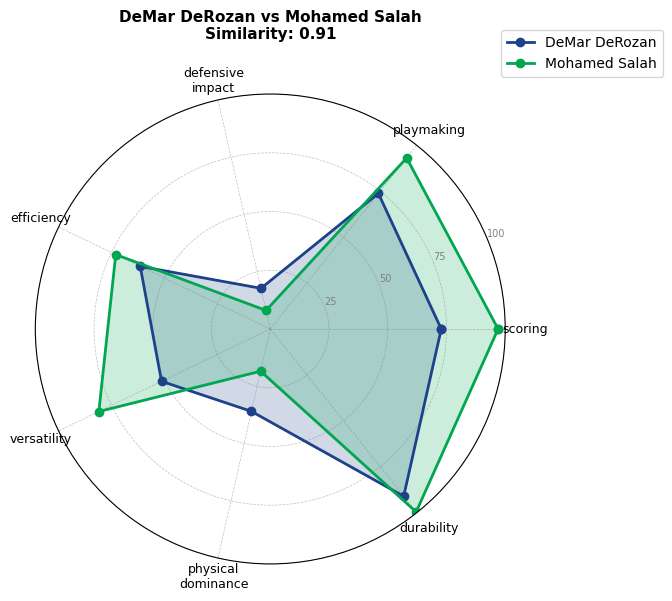

In [17]:
# Radar chart overlaying two players' 7 attributes on a 0-1 scale.
def radar_chart(player_a, player_b, save_path=None):
    data = get_comparison_data(player_a, player_b)
    
    attrs = ATTRS
    n = len(attrs)
    
    a_vals = [combined.loc[player_a, attr] for attr in attrs]
    b_vals = [combined.loc[player_b, attr] for attr in attrs]
    
    # Fix: evenly space angles across full circle
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]
    a_vals += a_vals[:1]
    b_vals += b_vals[:1]
    
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    
    ax.plot(angles, a_vals, 'o-', linewidth=2, label=player_a, color='#1d428a')
    ax.fill(angles, a_vals, alpha=0.20, color='#1d428a')
    ax.plot(angles, b_vals, 'o-', linewidth=2, label=player_b, color='#00a650')
    ax.fill(angles, b_vals, alpha=0.20, color='#00a650')
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([a.replace('_', '\n') for a in attrs], size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25', '50', '75', '100'], size=7, color='grey')
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
    
    sim = data['similarity']
    ax.set_title(f"{player_a} vs {player_b}\nSimilarity: {sim}",
                 size=11, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

radar_chart("DeMar DeRozan", "Mohamed Salah")

In [18]:
# Install UMAP (no-op if already present). Must run before the import in the next cell.
!pip install umap-learn

I0617 15:14:11.833185 9044653 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(78, generation: 1)
Defaulting to user installation because normal site-packages is not writeable


In [19]:
# Fit a 3D UMAP embedding of the combined pool and plot it interactively with Plotly.
import umap

# ---- Fit 3D UMAP ----
reducer_3d = umap.UMAP(
    n_components=3,
    n_neighbors=10,
    min_dist=0.05,
    metric='cosine',
    random_state=42
)

embedding_3d = reducer_3d.fit_transform(vectors_z[ATTRS].values)

# ---- Build dataframe with coordinates and metadata ----
umap_df = pd.DataFrame({
    'player': vectors_z.index,
    'sport': sport_of.values,
    'x': embedding_3d[:, 0],
    'y': embedding_3d[:, 1],
    'z': embedding_3d[:, 2],
})

# Add position info
nba_pos_map = dict(zip(df['Player'], df['Pos']))
soccer_pos_map = dict(zip(soccer_df['Player'], soccer_df['Pos'].str.split(',').str[0]))
pos_map = {**nba_pos_map, **soccer_pos_map}
umap_df['position'] = umap_df['player'].map(pos_map)

# Add dominant attribute
for attr in ATTRS:
    umap_df[attr] = vectors_z[ATTRS][attr].values
umap_df['dominant_attr'] = vectors_z[ATTRS].idxmax(axis=1)

# ---- Key players to label ----
label_players = [
    "Rudy Gobert", "Trae Young"
]
label_df = umap_df[umap_df['player'].isin(label_players)]

# ---- Base scatter ----
fig = px.scatter_3d(
    umap_df,
    x='x', y='y', z='z',
    color='sport',
    hover_name='player',
    hover_data={
        'x': False, 'y': False, 'z': False,
        'position': True,
        'dominant_attr': True,
        **{attr: ':.2f' for attr in ATTRS}
    },
    color_discrete_map={'basketball': '#1d428a', 'soccer': '#00a650'},
    opacity=0.6,
    title='Player Universe — NBA vs Soccer (UMAP 3D)'
)

fig.update_traces(marker=dict(size=4, line=dict(width=0)))

# ---- Add labeled key players ----
fig.add_trace(
    go.Scatter3d(
        x=label_df['x'],
        y=label_df['y'],
        z=label_df['z'],
        mode='markers+text',
        text=label_df['player'],
        textposition='top center',
        textfont=dict(size=10, color='white'),
        marker=dict(
            size=7,
            color='yellow',
            line=dict(width=1, color='white')
        ),
        name='Key Players',
        showlegend=True
    )
)

# ---- Layout ----
fig.update_layout(
    width=1000,
    height=750,
    legend=dict(title='Sport'),
    scene=dict(
        xaxis_title='',
        yaxis_title='',
        zaxis_title='',
        xaxis=dict(showticklabels=False, showgrid=True, zeroline=False),
        yaxis=dict(showticklabels=False, showgrid=True, zeroline=False),
        zaxis=dict(showticklabels=False, showgrid=True, zeroline=False),
        bgcolor='rgb(10, 10, 20)',
    ),
    paper_bgcolor='rgb(10, 10, 20)',
    font=dict(color='white'),
)

fig.show()

/Users/bryan.shao/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
I0617 15:14:28.729723 9045187 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(78, generation: 1)


In [20]:
# Compute player_dna labels and export all artifacts (index, UMAP, sim matrix, vectors, percentiles).
os.makedirs('exports', exist_ok=True)
player_index = umap_df[['player', 'sport', 'position']].copy()
player_index = player_index.sort_values('player')
print(player_index.shape)
player_index.head(10)
def player_dna(player, top_n=3):
    scores = vectors_z.loc[player, ATTRS].sort_values(ascending=False)
    
    def label(attr, score):
        if score > 1.5:
            return f"Elite {attr.replace('_', ' ').title()}"
        elif score > 0.5:
            return f"Strong {attr.replace('_', ' ').title()}"
        elif score < -1.0:
            return f"Limited {attr.replace('_', ' ').title()}"
        else:
            return None
    
    labels = [label(attr, score) for attr, score in scores.items()]
    labels = [l for l in labels if l is not None]
    return " · ".join(labels[:top_n])

# Test on key players
for p in ["Nikola Jokić", "Erling Haaland", "Rudy Gobert", "Trae Young", "Bukayo Saka"]:
    print(f"{p}: {player_dna(p)}")

# Add DNA to player index
player_index['dna'] = player_index['player'].apply(player_dna)
player_index.to_json('exports/player_index.json', orient='records', indent=2)



# UMAP coordinates + metadata
umap_df['dna'] = umap_df['player'].apply(player_dna)
umap_df[['player', 'sport', 'position', 'x', 'y', 'z', 'dominant_attr', 'dna'] + ATTRS].to_json('exports/umap_players.json', orient='records', indent=2)

# Similarity matrix
sim_matrix.to_csv('exports/sim_matrix.csv')

# Player attribute vectors
combined_export = combined[ATTRS + ['sport']].copy()
combined_export.index.name = 'player'
combined_export.to_json('exports/player_vectors.json', orient='index', indent=2)

# Percentile stats
nba_pct.to_json('exports/nba_pct.json', orient='records', indent=2)
soccer_pct.to_json('exports/soccer_pct.json', orient='records', indent=2)

print("All exports done")

(585, 3)
Nikola Jokić: Elite Versatility · Elite Efficiency · Elite Physical Dominance
Erling Haaland: Elite Scoring · Strong Durability · Limited Defensive Impact
Rudy Gobert: Elite Physical Dominance · Elite Defensive Impact · Strong Efficiency
Trae Young: Elite Playmaking · Strong Scoring · Strong Efficiency
Bukayo Saka: Elite Versatility · Elite Playmaking · Strong Scoring
All exports done


In [21]:
# Overall quality score: reward each player's strengths and breadth across attributes.
def overall_quality(player):
    scores = vectors_z.loc[player, ATTRS]
    
    # Only count positive contributions — reward strengths, ignore weaknesses
    positive_scores = scores[scores > 0]
    
    # Weighted: mean of positives + bonus for how many dimensions are strong
    if len(positive_scores) == 0:
        return 0.0
    
    strength_mean = positive_scores.mean()
    breadth_bonus = len(positive_scores) / len(ATTRS)  # 0 to 1
    
    return float(strength_mean * 0.7 + breadth_bonus * 0.3)

quality_scores = pd.Series(
    {player: overall_quality(player) for player in vectors_z.index},
    name='quality'
)

print("Quality score examples:")
for p in ["Nikola Jokić", "Joelinton", "Erling Haaland",
          "Rudy Gobert", "Trae Young", "Bukayo Saka",
          "Mohamed Salah", "Declan Rice", "James Harden", "Tyrese Maxey", "Joel Embiid"]:
    print(f"  {p}: {quality_scores[p]:.3f}")

print(f"\nMin: {quality_scores.min():.3f}")
print(f"Max: {quality_scores.max():.3f}")
print(f"Mean: {quality_scores.mean():.3f}")

Quality score examples:
  Nikola Jokić: 1.540
  Joelinton: 0.816
  Erling Haaland: 0.831
  Rudy Gobert: 1.267
  Trae Young: 0.981
  Bukayo Saka: 0.991
  Mohamed Salah: 1.272
  Declan Rice: 0.866
  James Harden: 0.950
  Tyrese Maxey: 1.046
  Joel Embiid: 0.998

Min: 0.000
Max: 1.540
Mean: 0.692


In [22]:
# Export the per-player quality scores to JSON.
quality_df = pd.DataFrame({
    'player': quality_scores.index,
    'quality': quality_scores.values
})
quality_df.to_json('exports/quality_scores.json', orient='records', indent=2)
print("Quality scores exported")

Quality scores exported
